<a href="https://www.kaggle.com/code/adegbaju/mental-health-burnout-in-tech-workers-2026-full?scriptVersionId=322091033" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# MENTAL HEALTH & BURNOUT IN TECH WORKERS 2026 - FULL ANALYSIS

 This notebook performs:
 1. Exploratory Data Analysis (EDA) with visualisations
 2. Feature engineering and preprocessing
 3. Predictive modelling for all three targets
 4. Model evaluation and feature importance

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score, precision_score, recall_score)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, RobustScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import joblib


# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)


# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


## Loading and Chec dataset

In [2]:
# Load dataset
df = pd.read_csv(r'/kaggle/input/datasets/mohankrishnathalla/mental-health-and-burnout-in-tech-workers-2026/mental_health_burnout_tech_2026.csv')
print('Shape:', df.shape)
df.head()

Shape: (100000, 36)


,employee_id,age,gender,country,job_role,seniority_level,years_experience,years_at_company,company_size,industry,...,autonomy_score,stress_score,burnout_score,phq9_score,phq9_category,gad7_score,gad7_category,burnout_level,seeks_mental_health_support,job_change_intention
0,1,33,Male,India,Software Engineer,Lead,11,6.4,Small (51-200),Healthcare Tech,...,6.1,10.0,10.0,19,Moderately Severe (15-19),12,Moderate (10-14),Severe,1,1
1,2,24,Non-binary,USA,Full Stack Developer,Manager,0,5.7,Startup (1-50),Fintech,...,5.4,9.3,7.0,8,Mild (5-9),6,Mild (5-9),High,1,1
2,3,36,Prefer not to say,USA,Software Engineer,Lead,14,5.6,Mid (201-1000),Fintech,...,4.1,8.9,8.5,8,Mild (5-9),9,Mild (5-9),Severe,0,1
3,4,38,Non-binary,USA,Software Engineer,Lead,14,1.2,Mid (201-1000),SaaS / Cloud,...,7.3,10.0,10.0,14,Moderate (10-14),11,Moderate (10-14),Severe,0,1
4,5,22,Non-binary,France,ML Engineer,Junior,0,3.0,Small (51-200),AI / ML Startup,...,4.4,7.7,5.4,8,Mild (5-9),0,Minimal (0-4),Moderate,1,0


In [3]:
# Initial check
print(df.info())
print('\nMissing values:')
print(df.isnull().sum().sum())  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   employee_id                  100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   country                      100000 non-null  object 
 4   job_role                     100000 non-null  object 
 5   seniority_level              100000 non-null  object 
 6   years_experience             100000 non-null  int64  
 7   years_at_company             100000 non-null  float64
 8   company_size                 100000 non-null  object 
 9   industry                     100000 non-null  object 
 10  work_mode                    100000 non-null  object 
 11  salary_usd                   100000 non-null  int64  
 12  work_hours_per_week          100000 non-null  int64  
 13  

#  Exploratory Data Analysis


## Target distributions

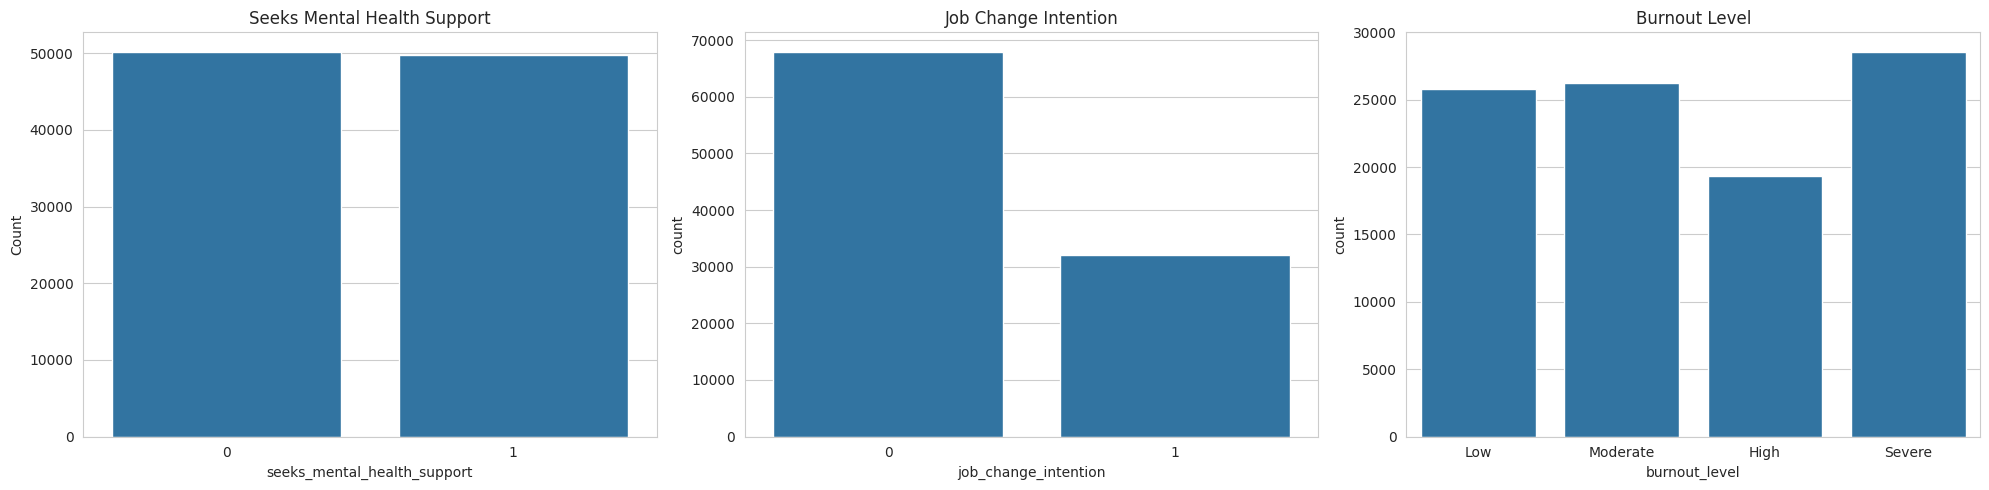

In [4]:
# --- Target distributions ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Binary targets
sns.countplot(x='seeks_mental_health_support', data=df, ax=axes[0])
axes[0].set_title('Seeks Mental Health Support')
axes[0].set_ylabel('Count')

sns.countplot(x='job_change_intention', data=df, ax=axes[1])
axes[1].set_title('Job Change Intention')

# Multi-class target
sns.countplot(x='burnout_level', data=df, order=['Low','Moderate','High','Severe'], ax=axes[2])
axes[2].set_title('Burnout Level')

plt.tight_layout()
plt.show()


In [5]:

print(df['seeks_mental_health_support'].value_counts(normalize=True))
print(df['job_change_intention'].value_counts(normalize=True))
print(df['burnout_level'].value_counts(normalize=True))

seeks_mental_health_support
0    0.50211
1    0.49789
Name: proportion, dtype: float64
job_change_intention
0    0.67998
1    0.32002
Name: proportion, dtype: float64
burnout_level
Severe      0.28576
Moderate    0.26255
Low         0.25807
High        0.19362
Name: proportion, dtype: float64


## Numerical features distributions

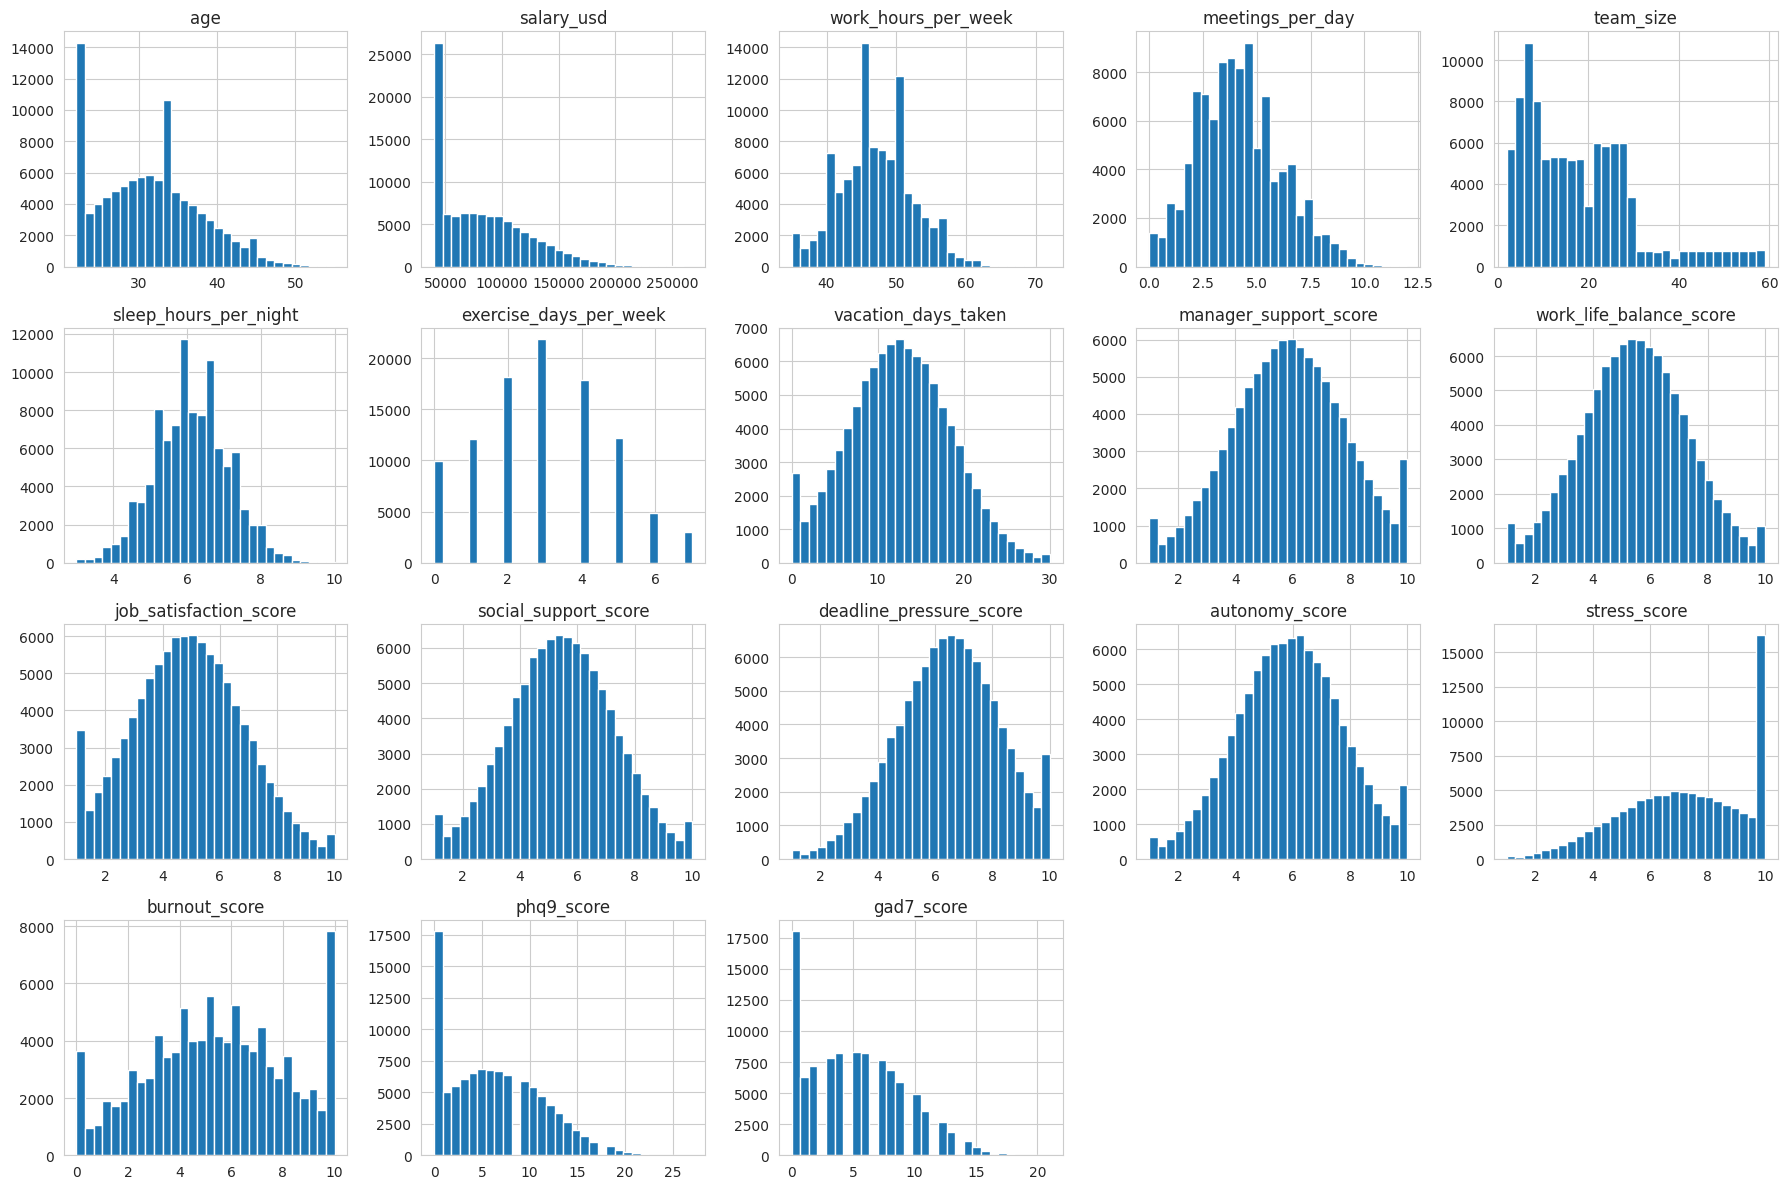

In [6]:
# --- Numerical features distributions ---
num_cols = ['age', 'salary_usd', 'work_hours_per_week', 'meetings_per_day', 'team_size',
            'sleep_hours_per_night', 'exercise_days_per_week', 'vacation_days_taken',
            'manager_support_score', 'work_life_balance_score', 'job_satisfaction_score',
            'social_support_score', 'deadline_pressure_score', 'autonomy_score',
            'stress_score', 'burnout_score', 'phq9_score', 'gad7_score']

df[num_cols].hist(bins=30, figsize=(18, 12), layout=(4,5))
plt.tight_layout()
plt.show()

## Categorical feature frequency

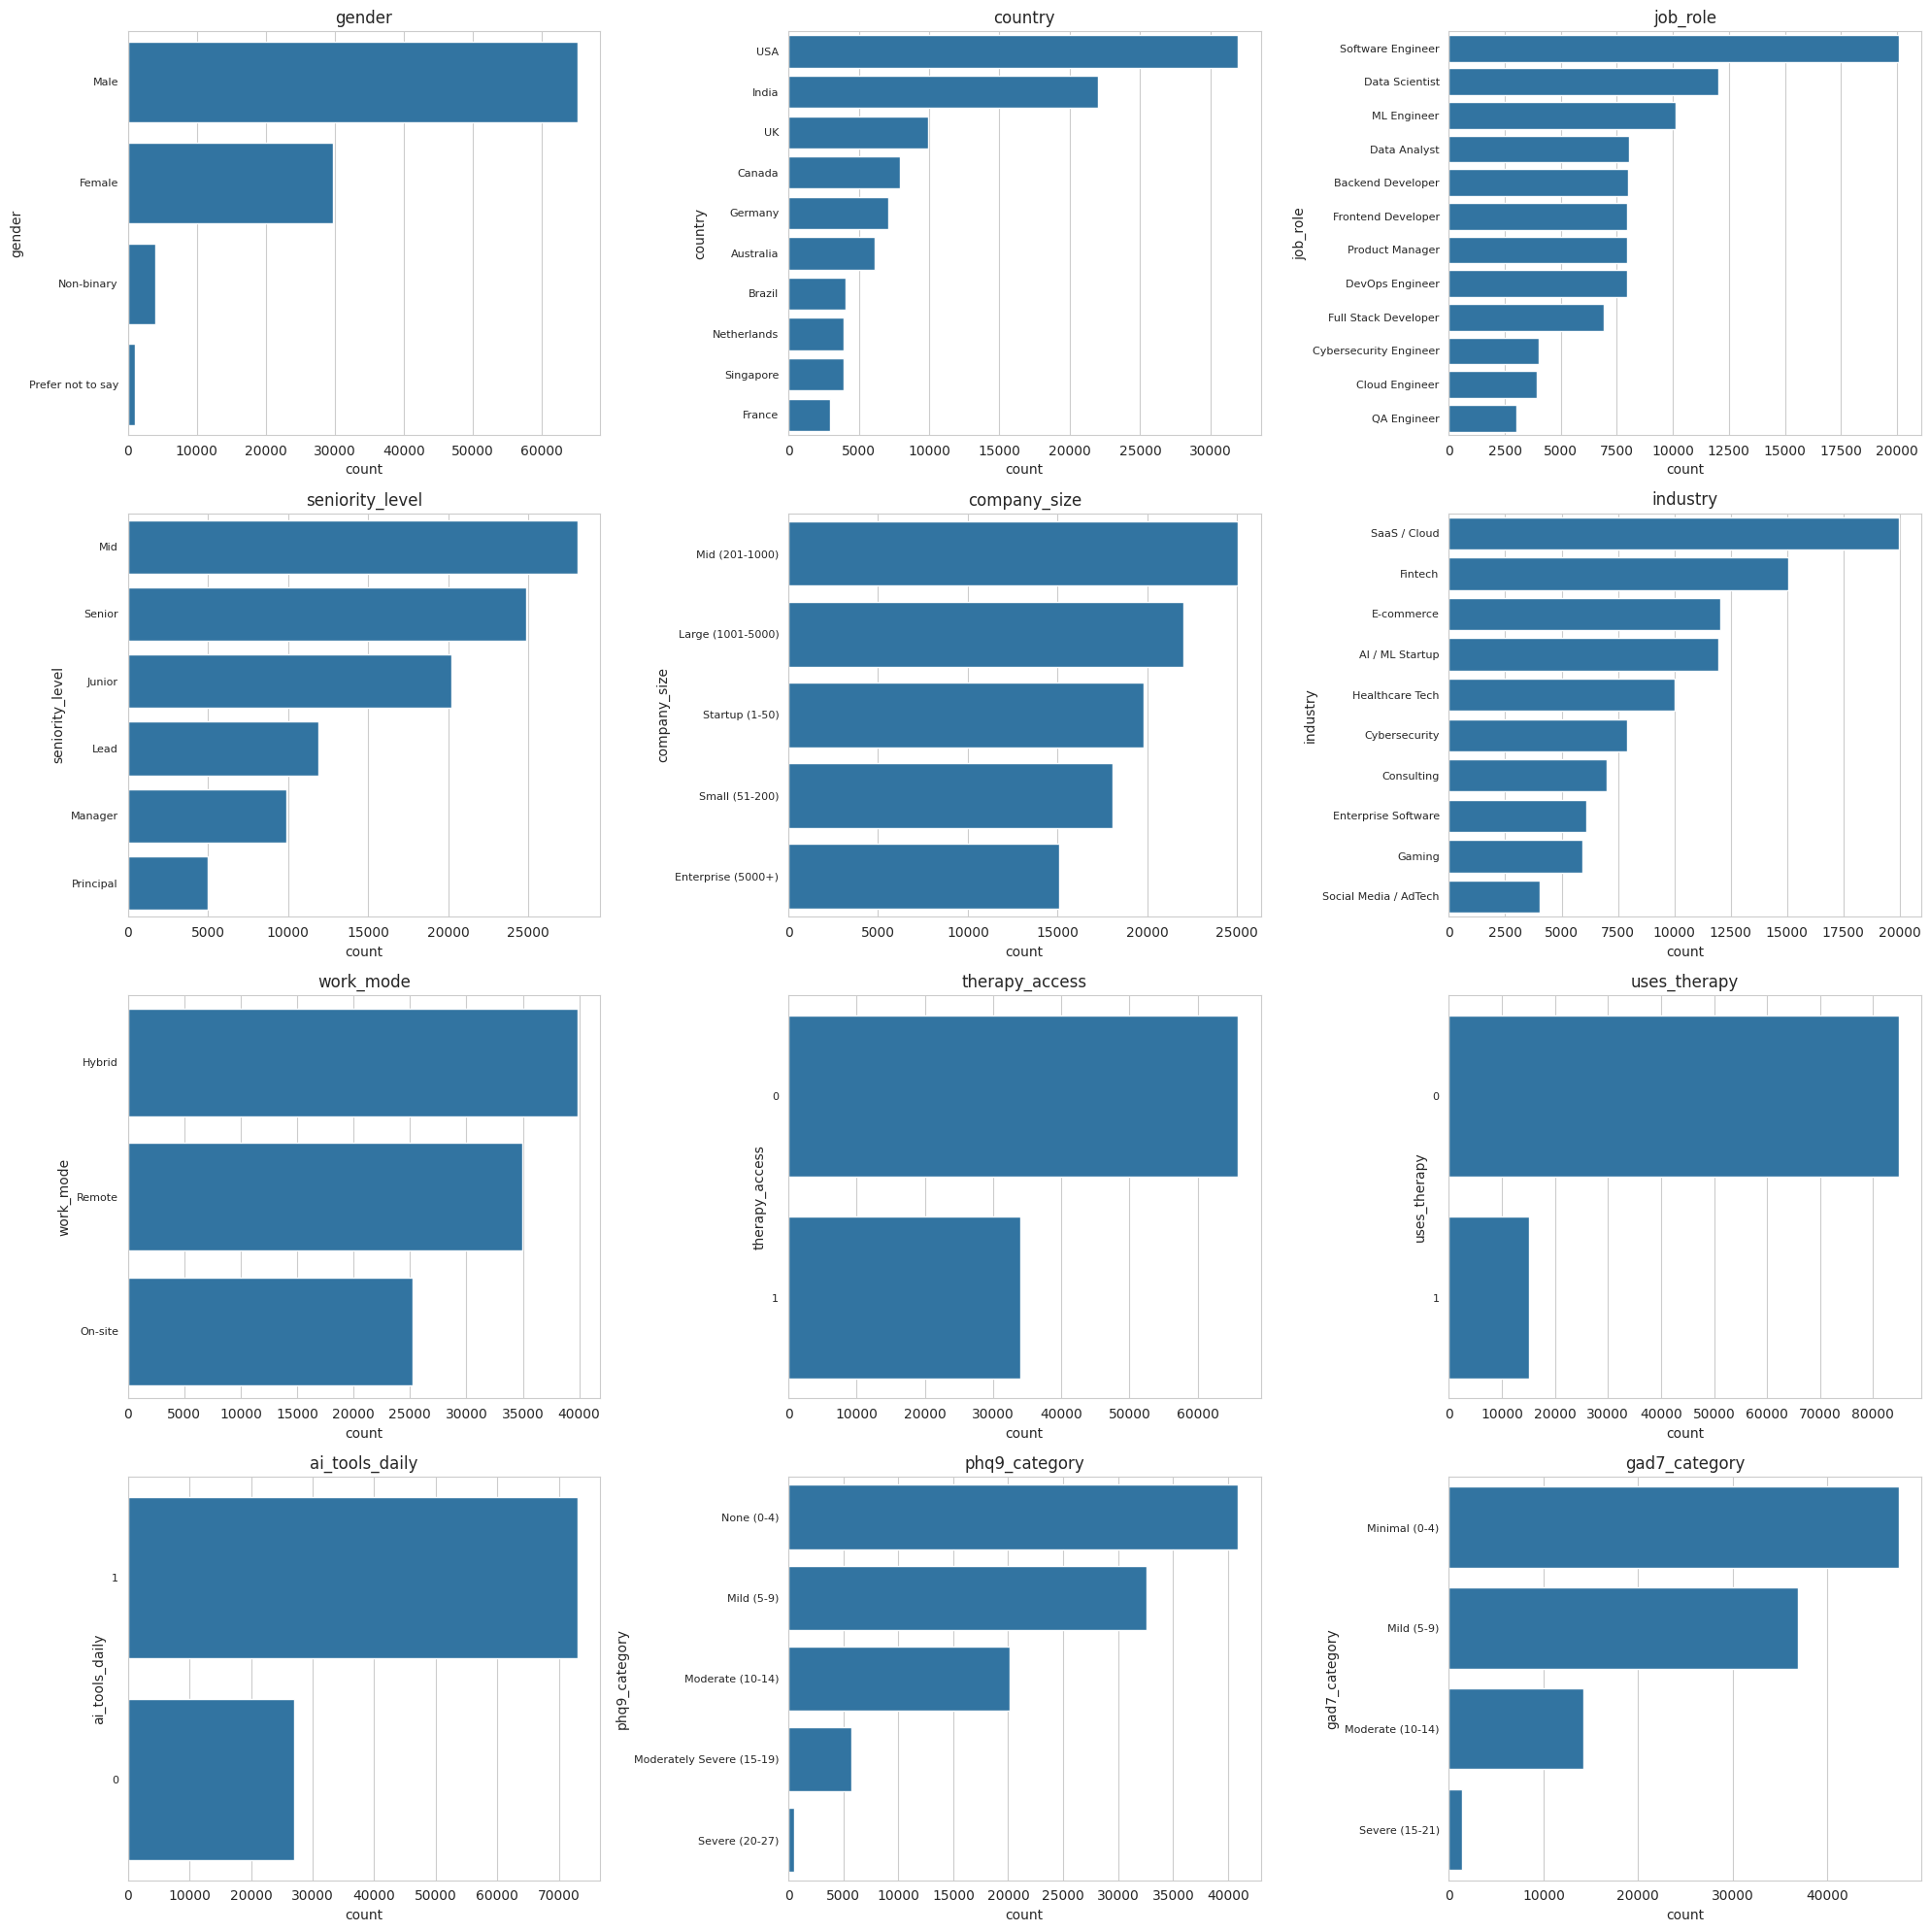

In [7]:
# --- Categorical feature frequency ---
cat_cols = ['gender', 'country', 'job_role', 'seniority_level', 'company_size',
            'industry', 'work_mode', 'therapy_access', 'uses_therapy', 'ai_tools_daily',
            'phq9_category', 'gad7_category']

fig, axes = plt.subplots(4, 3, figsize=(20, 20))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(y=col, data=df, order=df[col].value_counts().index, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()


## Key relationships from dataset description


#### Burnout vs Sleep hours (the strongest protective factor)

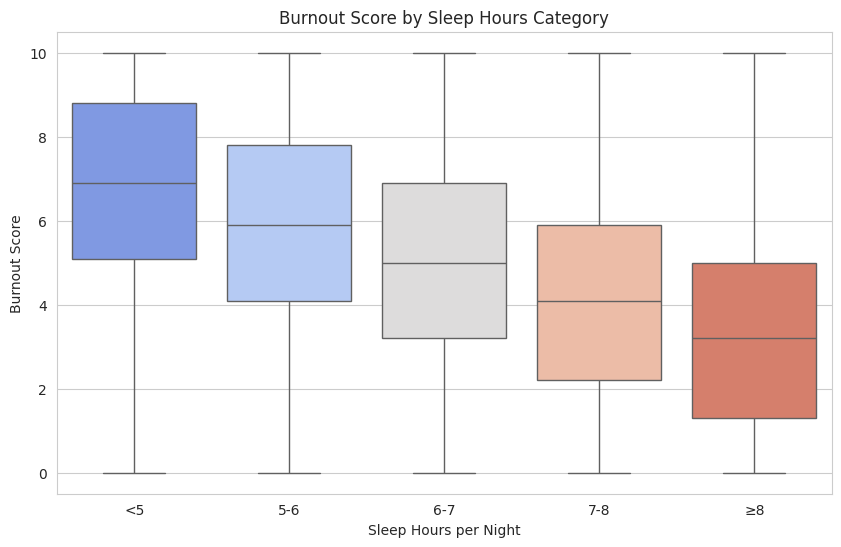

In [8]:
# Burnout vs Sleep hours (the strongest protective factor)
plt.figure(figsize=(10,6))
sns.boxplot(x=pd.cut(df['sleep_hours_per_night'], bins=[0,5,6,7,8,12],
                     labels=['<5','5-6','6-7','7-8','≥8']),
            y='burnout_score', data=df, palette='coolwarm')
plt.title('Burnout Score by Sleep Hours Category')
plt.xlabel('Sleep Hours per Night')
plt.ylabel('Burnout Score')
plt.show()

#### Sleep hours mean by burnout level

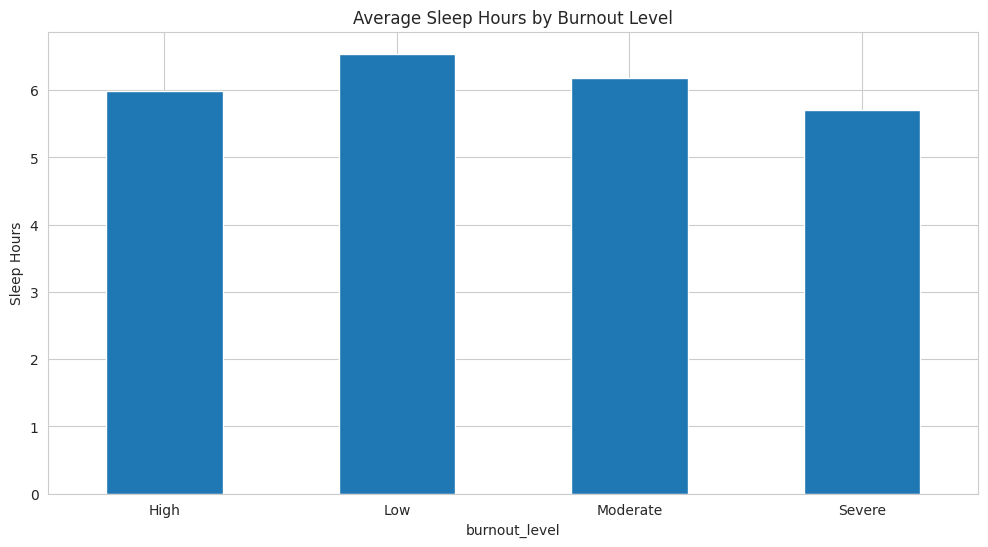

In [9]:
# Sleep hours mean by burnout level
df.groupby('burnout_level')['sleep_hours_per_night'].mean().plot(kind='bar')
plt.title('Average Sleep Hours by Burnout Level')
plt.ylabel('Sleep Hours')
plt.xticks(rotation=0)
plt.show()

#### Gender gap in burnout

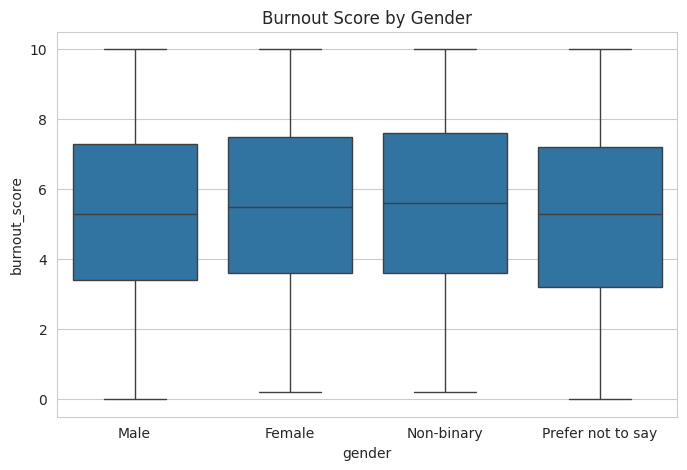

In [10]:
# Gender gap in burnout
plt.figure(figsize=(8,5))
sns.boxplot(x='gender', y='burnout_score', data=df, order=['Male','Female','Non-binary','Prefer not to say'])
plt.title('Burnout Score by Gender')
plt.show()

#### Remote vs On-site depression (PHQ-9)

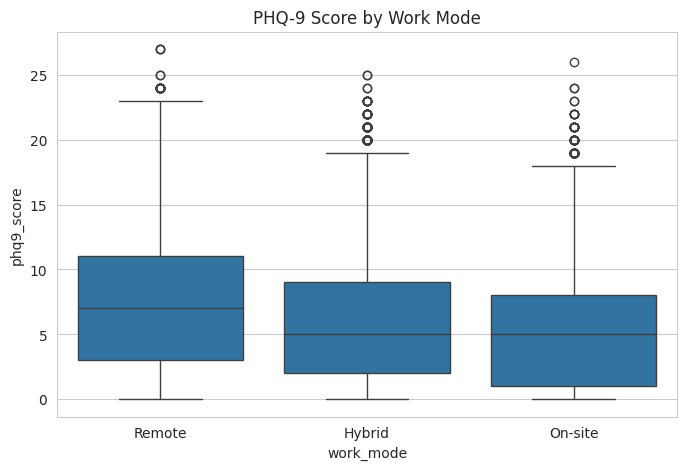

In [11]:
# Remote vs On-site depression (PHQ-9)
plt.figure(figsize=(8,5))
sns.boxplot(x='work_mode', y='phq9_score', data=df)
plt.title('PHQ-9 Score by Work Mode')
plt.show()

#### Meetings drive stress

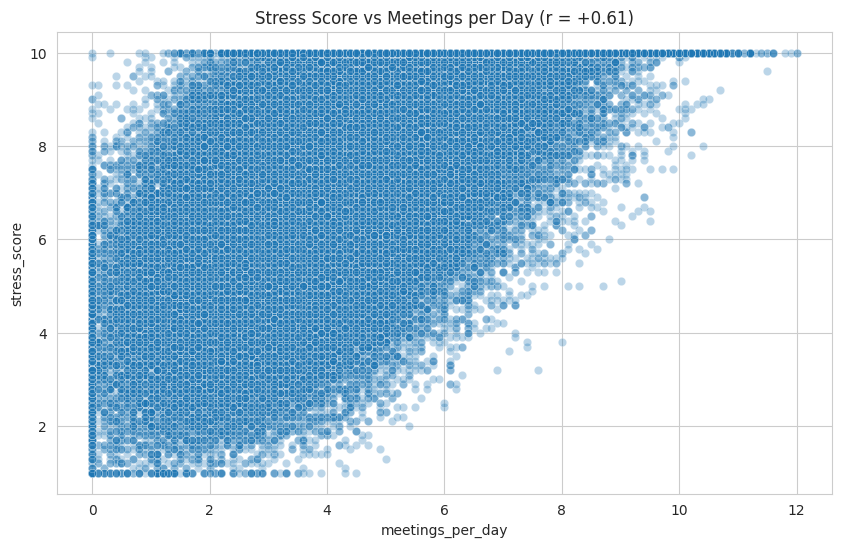

In [12]:
# Meetings drive stress
plt.figure(figsize=(10,6))
sns.scatterplot(x='meetings_per_day', y='stress_score', data=df, alpha=0.3)
plt.title('Stress Score vs Meetings per Day (r = +0.61)')
plt.show()

#### AI tools and anxiety (GAD-7)

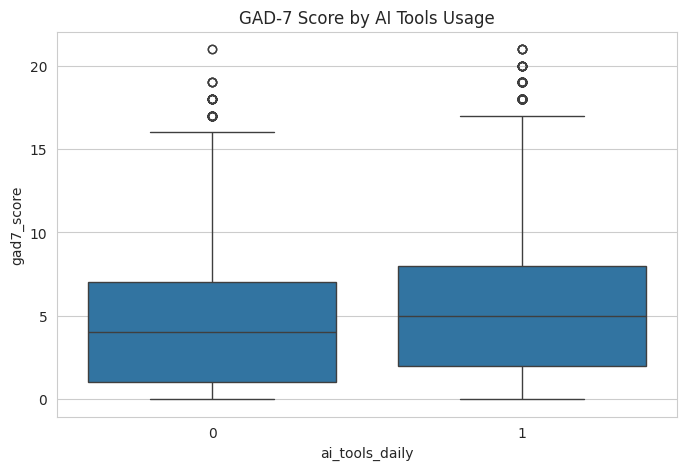

In [13]:
# AI tools and anxiety (GAD-7)
plt.figure(figsize=(8,5))
sns.boxplot(x='ai_tools_daily', y='gad7_score', data=df)
plt.title('GAD-7 Score by AI Tools Usage')
plt.show()


#### Therapy access effectiveness

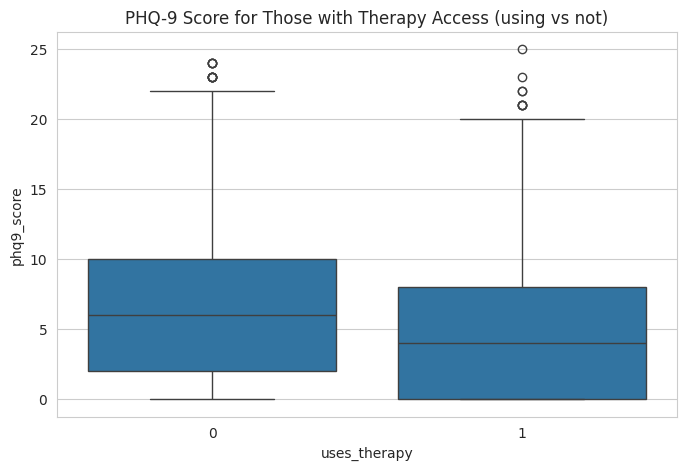

In [14]:
# Therapy access effectiveness
plt.figure(figsize=(8,5))
sns.boxplot(x='uses_therapy', y='phq9_score', data=df[df['therapy_access']==1])
plt.title('PHQ-9 Score for Those with Therapy Access (using vs not)')
plt.show()

## Correlation heatmap for numerical features

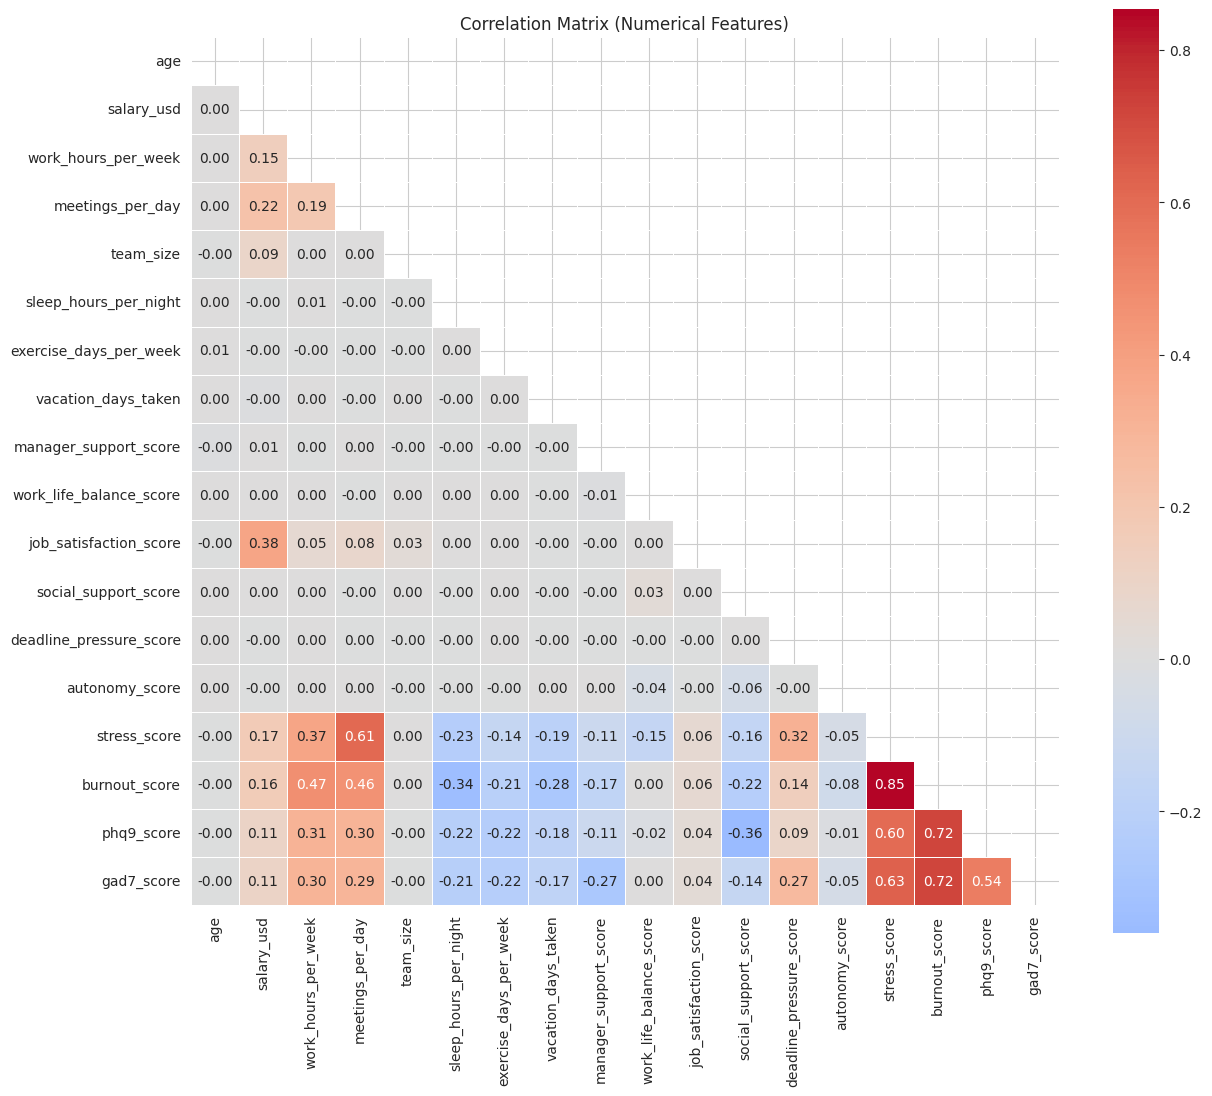

In [15]:
# --- Correlation heatmap for numerical features ---
plt.figure(figsize=(14,12))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=.5)
plt.title('Correlation Matrix (Numerical Features)')
plt.show()

# Preprocessing & Feature Engineering

In [16]:
# Define features and targets
targets = {
    'burnout_level': 'multi',          # 4 classes
    'seeks_mental_health_support': 'binary',
    'job_change_intention': 'binary'
}

# We'll drop identifiers and redundant columns
drop_cols = ['employee_id']  # identifier

# Common categorical and numerical columns for all targets
base_cat_cols = ['gender', 'country', 'job_role', 'seniority_level', 'company_size',
                 'industry', 'work_mode', 'therapy_access', 'uses_therapy', 'ai_tools_daily']
base_num_cols = ['age', 'salary_usd', 'work_hours_per_week', 'meetings_per_day', 'team_size',
                 'sleep_hours_per_night', 'exercise_days_per_week', 'vacation_days_taken',
                 'manager_support_score', 'work_life_balance_score', 'job_satisfaction_score',
                 'social_support_score', 'deadline_pressure_score', 'autonomy_score', 'stress_score']

# Keep stress_score and other workplace factors.
burnout_feature_num = [c for c in base_num_cols if c not in ['burnout_score']]
burnout_feature_cat = base_cat_cols.copy()

# For mental health support: we can keep clinical scores as they reflect need for support.
# But be cautious: phq9_category and gad7_category are derived from scores, so drop categories.
mh_feature_num = base_num_cols + ['phq9_score', 'gad7_score']  # keep clinical scores
mh_feature_cat = base_cat_cols + []  # maybe add phq9_category? Not needed.

# For job change intention: similar to burnout, might keep clinical scores as predictors.
job_feature_num = base_num_cols + ['phq9_score', 'gad7_score']
job_feature_cat = base_cat_cols.copy()


## Preprocessing pipeline with ColumnTransformer

In [17]:
def build_preprocessor(cat_cols, num_cols, drop_cat='first'):
    """Create a column transformer for scaling numericals and one-hot encoding categoricals."""
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop=drop_cat))
    ])
    numerical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, num_cols),
            ('cat', categorical_transformer, cat_cols)
        ])
    return preprocessor


# Modelling

In [18]:
# Helper function to evaluate binary classifiers
def evaluate_binary(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.show()
    return model

# Helper for multi-class
def evaluate_multiclass(model, X_train, X_test, y_train, y_test, class_names):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_names))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.show()
    return model


## Target: `seeks_mental_health_support` (Binary)


Logistic Regression - seeks_mental_health_support
Accuracy: 0.654
ROC-AUC: 0.7126235306790812

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.69      0.67     10042
           1       0.66      0.62      0.64      9958

    accuracy                           0.65     20000
   macro avg       0.65      0.65      0.65     20000
weighted avg       0.65      0.65      0.65     20000



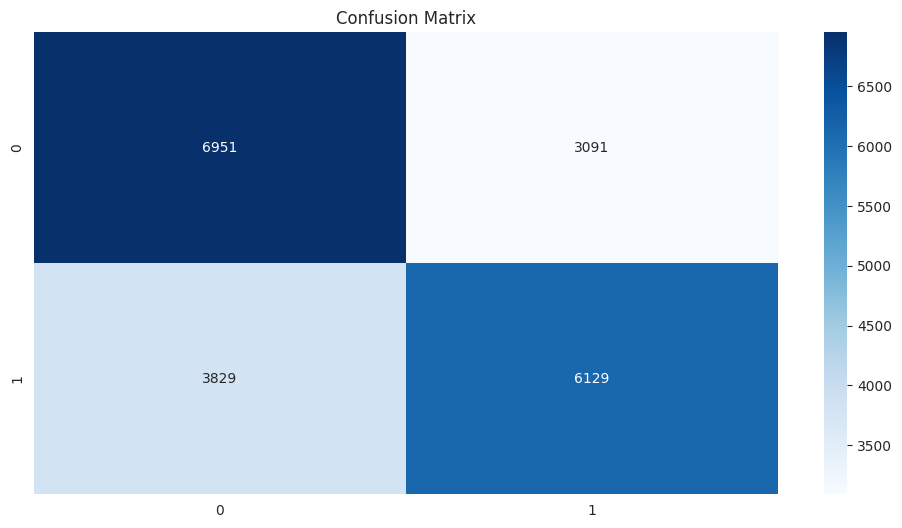


Random Forest - seeks_mental_health_support
Accuracy: 0.64475
ROC-AUC: 0.6998301350035816

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.69      0.66     10042
           1       0.66      0.60      0.63      9958

    accuracy                           0.64     20000
   macro avg       0.65      0.64      0.64     20000
weighted avg       0.65      0.64      0.64     20000



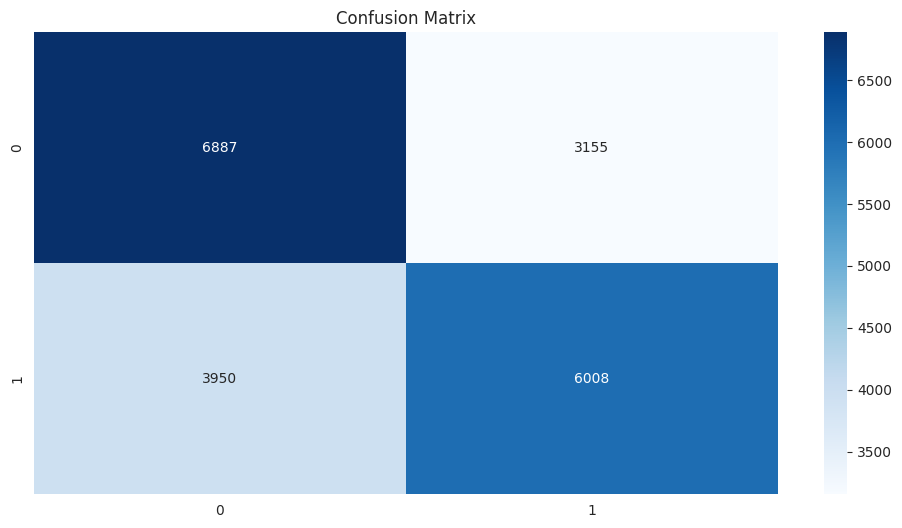


XGBoost - seeks_mental_health_support
Accuracy: 0.64155
ROC-AUC: 0.6951265020314957

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.68      0.66     10042
           1       0.65      0.60      0.63      9958

    accuracy                           0.64     20000
   macro avg       0.64      0.64      0.64     20000
weighted avg       0.64      0.64      0.64     20000



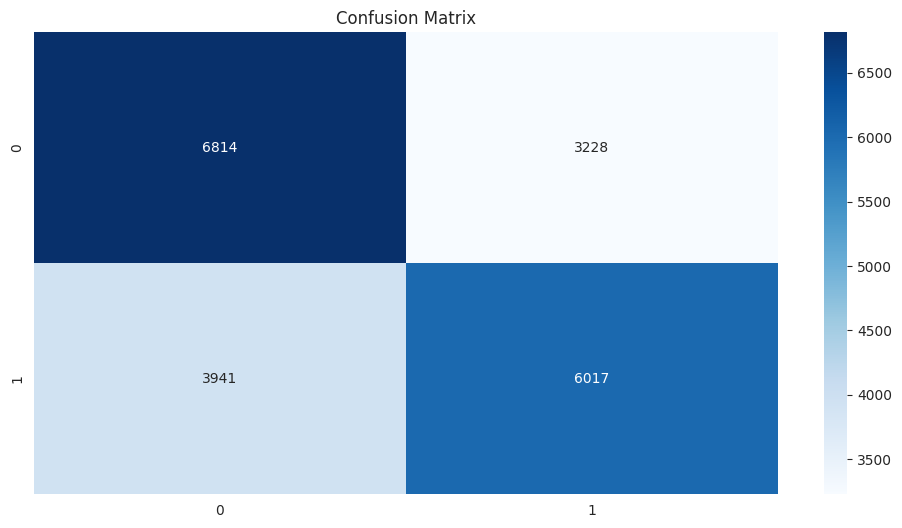

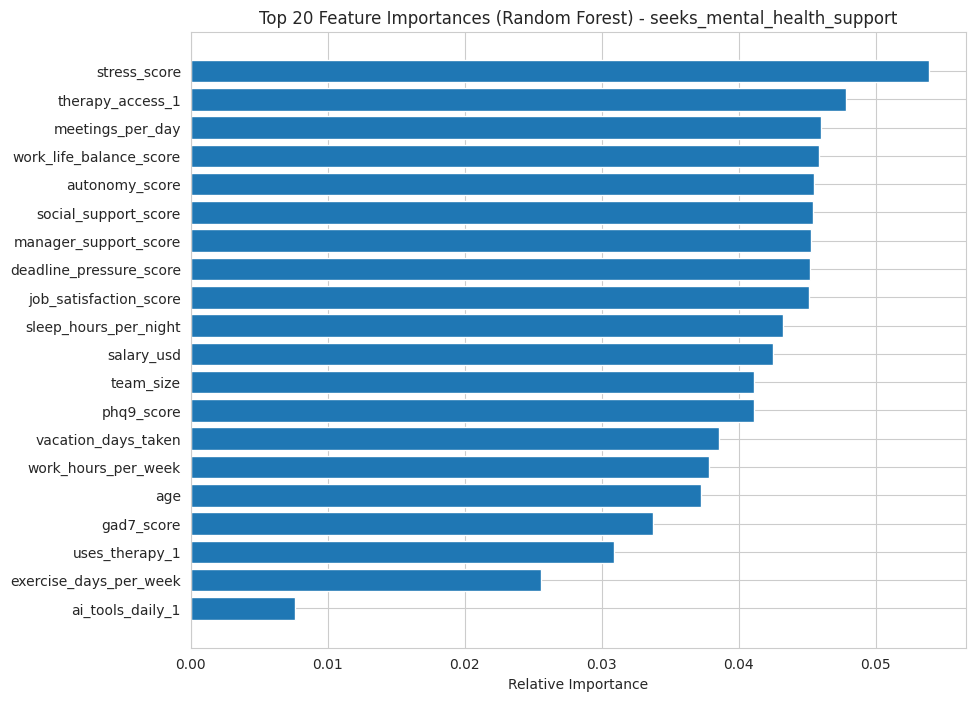

In [19]:
# Prepare data
X = df.drop(columns=['employee_id', 'seeks_mental_health_support', 'job_change_intention',
                     'burnout_level', 'phq9_category', 'gad7_category'])  # exclude target & redundant categories
y = df['seeks_mental_health_support']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Build preprocessing
cat_features = [c for c in mh_feature_cat if c in X.columns]
num_features = [c for c in mh_feature_num if c in X.columns]
preprocessor = build_preprocessor(cat_features, num_features, drop_cat='first')

# Logistic Regression pipeline
pipe_lr = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', LogisticRegression(max_iter=1000, random_state=42))])
print("Logistic Regression - seeks_mental_health_support")
evaluate_binary(pipe_lr, X_train, X_test, y_train, y_test)

# Random Forest
pipe_rf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))])
print("\nRandom Forest - seeks_mental_health_support")
evaluate_binary(pipe_rf, X_train, X_test, y_train, y_test)

# XGBoost (can use label encoded y directly, but pipeline works)
pipe_xgb = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', XGBClassifier(eval_metric='logloss', random_state=42, use_label_encoder=False))])
print("\nXGBoost - seeks_mental_health_support")
evaluate_binary(pipe_xgb, X_train, X_test, y_train, y_test)

# Feature importance from Random Forest
rf_model = pipe_rf.named_steps['classifier']
# Get feature names after one-hot encoding
feature_names = (num_features +
                 list(pipe_rf.named_steps['preprocessor'].named_transformers_['cat']
                      .named_steps['onehot'].get_feature_names_out(cat_features)))
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-20:]
plt.figure(figsize=(10,8))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.title('Top 20 Feature Importances (Random Forest) - seeks_mental_health_support')
plt.show()


## Target: `job_change_intention` (Binary)


Logistic Regression - job_change_intention
Accuracy: 0.6902
ROC-AUC: 0.680314315257353

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.92      0.80     13600
           1       0.54      0.20      0.29      6400

    accuracy                           0.69     20000
   macro avg       0.63      0.56      0.54     20000
weighted avg       0.66      0.69      0.64     20000



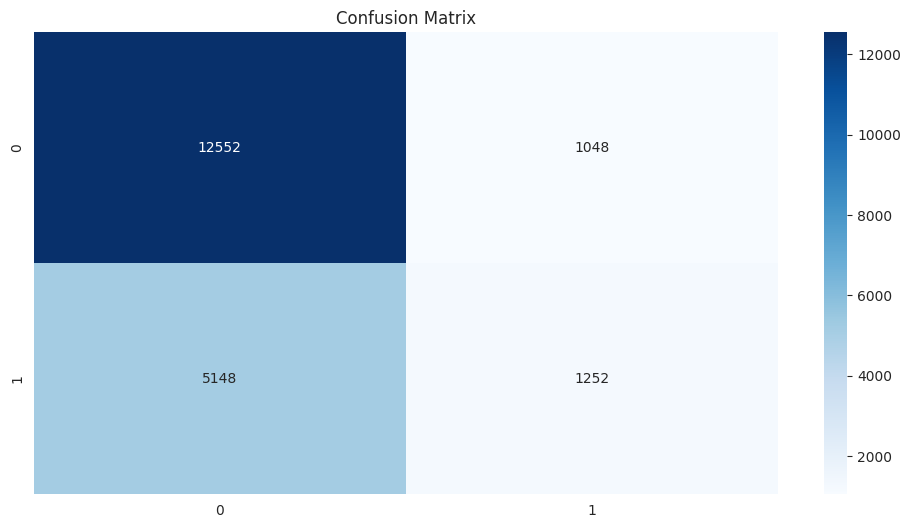


Random Forest - job_change_intention
Accuracy: 0.68685
ROC-AUC: 0.6627950482536765

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.94      0.80     13600
           1       0.54      0.15      0.23      6400

    accuracy                           0.69     20000
   macro avg       0.62      0.54      0.52     20000
weighted avg       0.65      0.69      0.62     20000



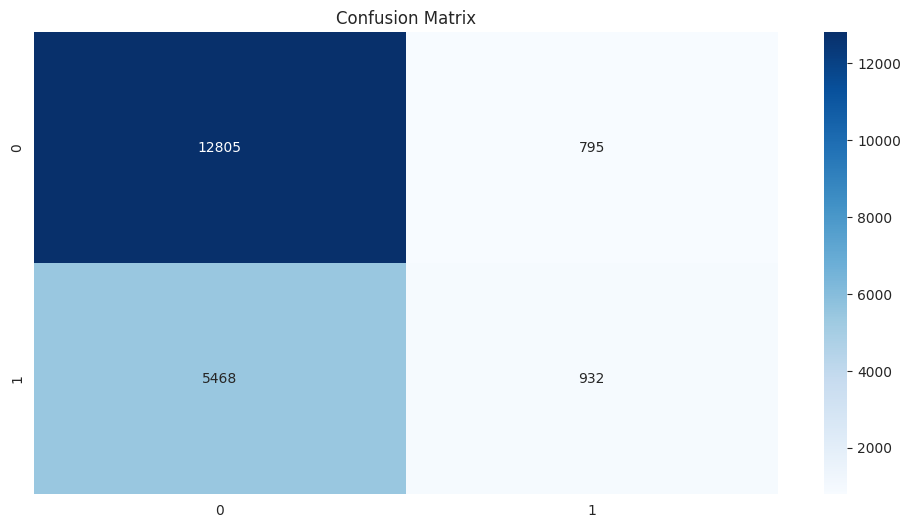


XGBoost - job_change_intention
Accuracy: 0.68135
ROC-AUC: 0.6587316693474264

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.90      0.79     13600
           1       0.50      0.22      0.30      6400

    accuracy                           0.68     20000
   macro avg       0.61      0.56      0.55     20000
weighted avg       0.64      0.68      0.64     20000



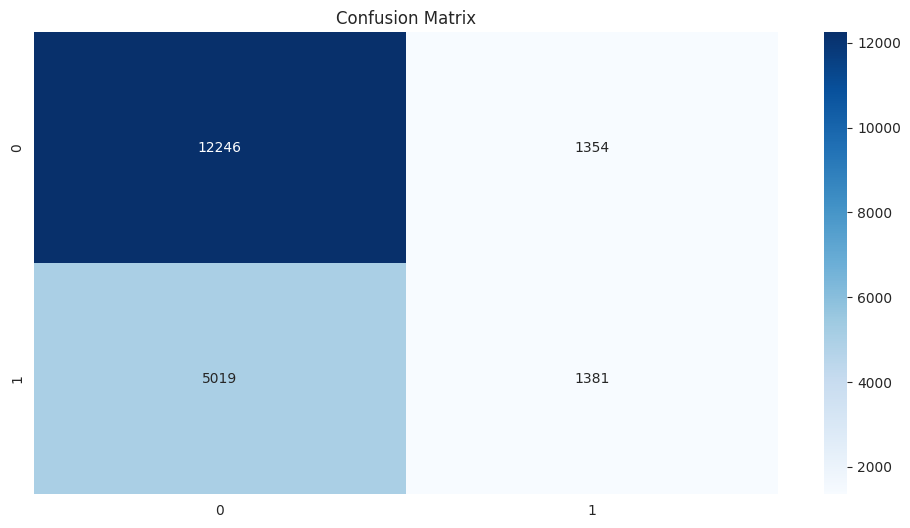

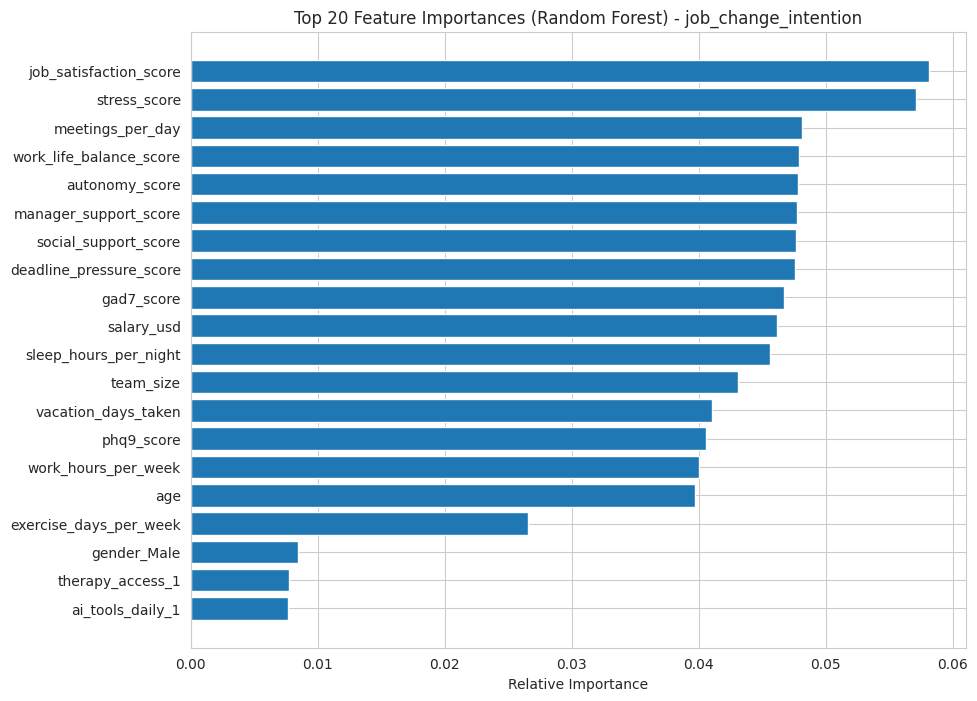

In [20]:
X = df.drop(columns=['employee_id', 'seeks_mental_health_support', 'job_change_intention',
                     'burnout_level', 'phq9_category', 'gad7_category'])
y = df['job_change_intention']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

cat_features = [c for c in job_feature_cat if c in X.columns]
num_features = [c for c in job_feature_num if c in X.columns]
preprocessor = build_preprocessor(cat_features, num_features, drop_cat='first')

# Logistic Regression
pipe_lr = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', LogisticRegression(max_iter=1000, random_state=42))])
print("Logistic Regression - job_change_intention")
evaluate_binary(pipe_lr, X_train, X_test, y_train, y_test)

# Random Forest
pipe_rf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))])
print("\nRandom Forest - job_change_intention")
evaluate_binary(pipe_rf, X_train, X_test, y_train, y_test)

# XGBoost
pipe_xgb = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', XGBClassifier(eval_metric='logloss', random_state=42, use_label_encoder=False))])
print("\nXGBoost - job_change_intention")
evaluate_binary(pipe_xgb, X_train, X_test, y_train, y_test)

# Feature importance
rf_model = pipe_rf.named_steps['classifier']
feature_names = (num_features +
                 list(pipe_rf.named_steps['preprocessor'].named_transformers_['cat']
                      .named_steps['onehot'].get_feature_names_out(cat_features)))
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-20:]
plt.figure(figsize=(10,8))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.title('Top 20 Feature Importances (Random Forest) - job_change_intention')
plt.show()


## Target: `burnout_level` (Multi‑class)

Random Forest - burnout_level
Accuracy: 0.6772

Classification Report:
               precision    recall  f1-score   support

        High       0.48      0.29      0.36      3873
         Low       0.80      0.79      0.80      5161
    Moderate       0.55      0.64      0.59      5251
      Severe       0.77      0.87      0.82      5715

    accuracy                           0.68     20000
   macro avg       0.65      0.65      0.64     20000
weighted avg       0.66      0.68      0.66     20000



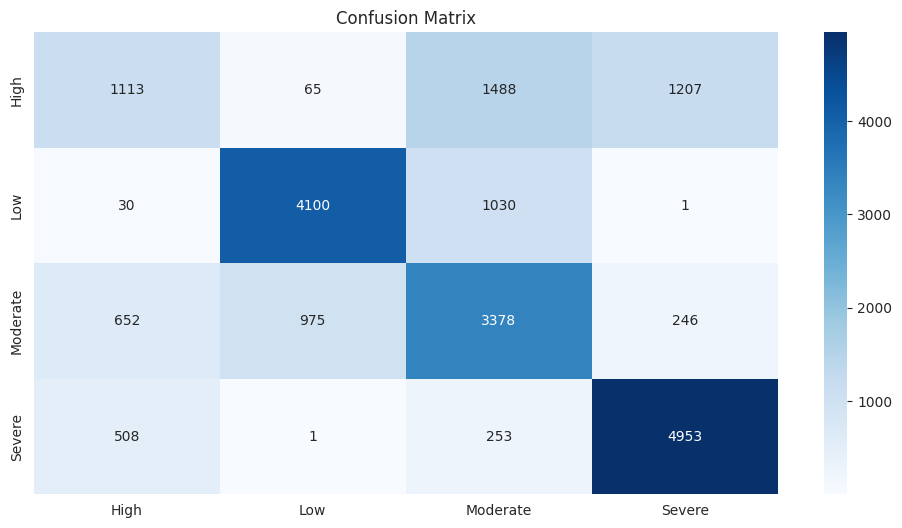


XGBoost - burnout_level
Accuracy: 0.6993

Classification Report:
               precision    recall  f1-score   support

        High       0.50      0.45      0.48      3873
         Low       0.83      0.79      0.81      5161
    Moderate       0.59      0.65      0.62      5251
      Severe       0.82      0.83      0.83      5715

    accuracy                           0.70     20000
   macro avg       0.68      0.68      0.68     20000
weighted avg       0.70      0.70      0.70     20000



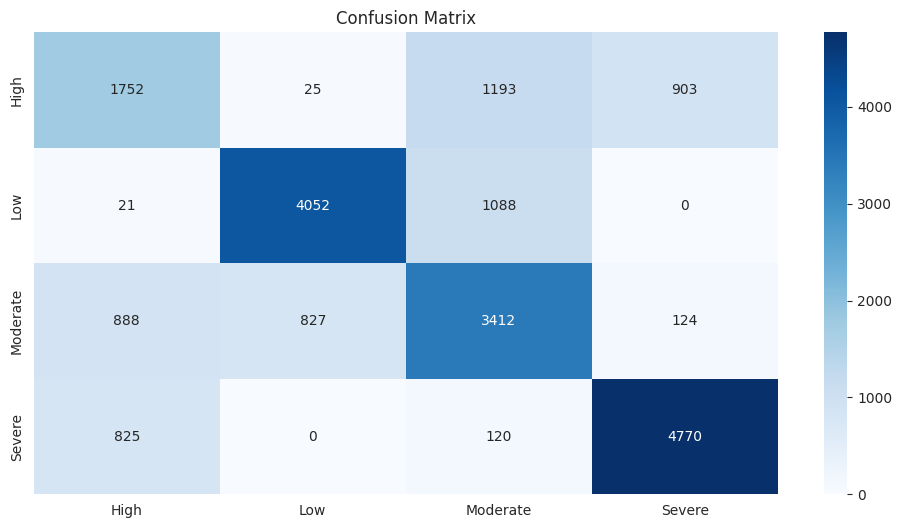

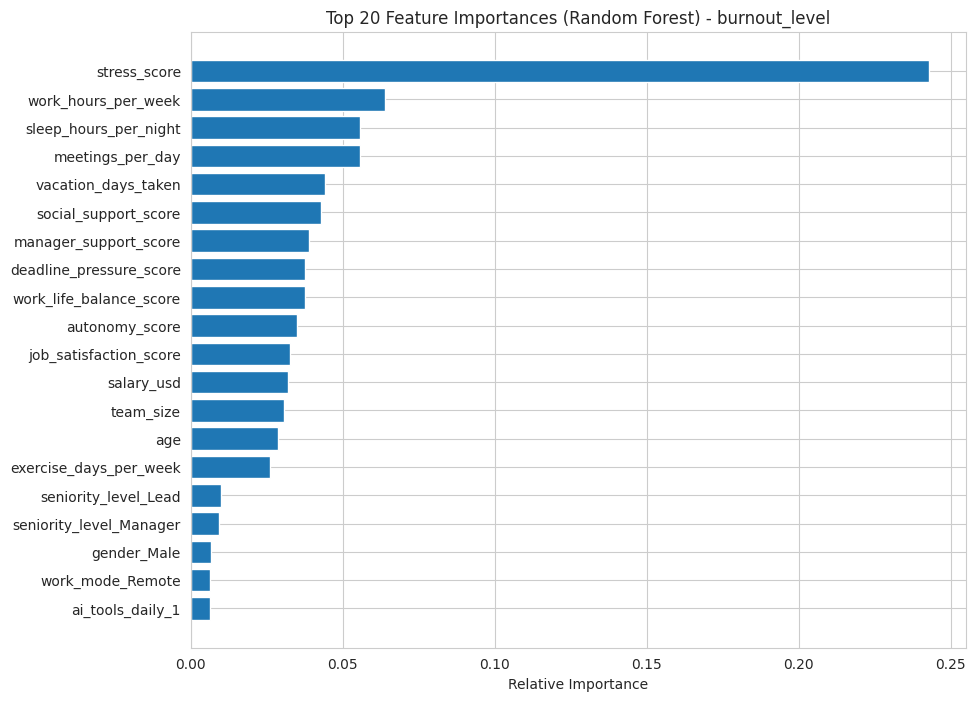

In [21]:
# Encode target label
le = LabelEncoder()
df['burnout_label'] = le.fit_transform(df['burnout_level'])  # Low:0, Moderate:1, High:2, Severe:3 (alphabetical)
class_names = le.classes_

# Features: exclude burnout_score and the clinical categories, but keep stress_score etc.
X = df.drop(columns=['employee_id', 'burnout_level', 'burnout_label', 'burnout_score',
                     'phq9_score', 'phq9_category', 'gad7_score', 'gad7_category',
                     'seeks_mental_health_support', 'job_change_intention'])
y = df['burnout_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

cat_features = [c for c in burnout_feature_cat if c in X.columns]
num_features = [c for c in burnout_feature_num if c in X.columns]
preprocessor = build_preprocessor(cat_features, num_features, drop_cat='first')  # tree models can handle all

# Random Forest (multi-class)
pipe_rf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))])
print("Random Forest - burnout_level")
evaluate_multiclass(pipe_rf, X_train, X_test, y_train, y_test, class_names)

# XGBoost (multi-class)
pipe_xgb = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', XGBClassifier(objective='multi:softmax', num_class=4,
                                                       eval_metric='mlogloss', random_state=42, use_label_encoder=False))])
print("\nXGBoost - burnout_level")
evaluate_multiclass(pipe_xgb, X_train, X_test, y_train, y_test, class_names)

# Feature importance from Random Forest
rf_model = pipe_rf.named_steps['classifier']
feature_names = (num_features +
                 list(pipe_rf.named_steps['preprocessor'].named_transformers_['cat']
                      .named_steps['onehot'].get_feature_names_out(cat_features)))
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-20:]
plt.figure(figsize=(10,8))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.title('Top 20 Feature Importances (Random Forest) - burnout_level')
plt.show()


#  Advanced Preprocessing and Robust Pipelines

## Define reusable feature lists and target dictionary

In [22]:
# All original columns
all_cols = df.columns.tolist()

# Identifiers and non-features
id_col = 'employee_id'

# Targets (we will model all three)
target_cols = {
    'burnout_level': 'burnout_level',          # multi-class
    'seeks_mental_health_support': 'seeks_mental_health_support',  # binary
    'job_change_intention': 'job_change_intention'                # binary
}

# Clinical scores that are direct measurements of the targets and should be excluded
# to avoid data leakage (they are essentially the target labels in continuous form)
excluded_for_burnout = ['burnout_score', 'phq9_score', 'phq9_category', 'gad7_score', 'gad7_category']
excluded_for_mental_health = ['phq9_category', 'gad7_category']  # keep scores
excluded_for_job_change = ['phq9_category', 'gad7_category']

# Base numeric columns (without any clinical scores)
base_num = ['age', 'salary_usd', 'work_hours_per_week', 'meetings_per_day', 'team_size',
            'sleep_hours_per_night', 'exercise_days_per_week', 'vacation_days_taken',
            'manager_support_score', 'work_life_balance_score', 'job_satisfaction_score',
            'social_support_score', 'deadline_pressure_score', 'autonomy_score', 'stress_score']

# Base categorical columns
base_cat = ['gender', 'country', 'job_role', 'seniority_level', 'company_size',
            'industry', 'work_mode', 'therapy_access', 'uses_therapy', 'ai_tools_daily']


## Advanced preprocessing pipeline with outlier handling

In [23]:
def create_preprocessor(num_cols, cat_cols):
    """
    Creates a ColumnTransformer that:
    - Caps extreme outliers at 1st and 99th percentiles (using FunctionTransformer)
    - Applies PowerTransformer for numerical features (makes them more Gaussian)
    - Scales numerical features with RobustScaler
    - One-hot encodes categorical features (dropping first category)
    """
    from sklearn.preprocessing import FunctionTransformer
    import numpy as np
    
    # Custom outlier capping
    def cap_outliers(X):
        X = np.array(X)
        for i in range(X.shape[1]):
            col = X[:, i]
            lower = np.percentile(col, 1)
            upper = np.percentile(col, 99)
            X[:, i] = np.clip(col, lower, upper)
        return X
    
    outlier_capper = FunctionTransformer(cap_outliers, validate=False)
    
    numeric_transformer = Pipeline(steps=[
        ('outlier_cap', outlier_capper),
        ('power', PowerTransformer(method='yeo-johnson')),
        ('scaler', RobustScaler())
    ])
    
    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_cols),
            ('cat', categorical_transformer, cat_cols)
        ],
        remainder='drop'  # drop any columns not specified
    )
    return preprocessor


# Cross‑validated Model Evaluation (Baseline without Tuning)

In [24]:
def evaluate_model_cv(model, X, y, preprocessor, cv_folds=5, classification_type='binary'):
    """
    Performs stratified k-fold cross-validation and returns a DataFrame of metrics.
    Handles both binary and multi-class.
    """
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', model)])
    
    # Define scoring metrics
    if classification_type == 'binary':
        scoring = ['accuracy', 'roc_auc', 'f1', 'precision', 'recall']
    else:
        scoring = ['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted']
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=SEED)
    scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1,
                            return_train_score=False)
    
    # Compile results
    results = {}
    for metric in scoring:
        results[metric] = [np.mean(scores[f'test_{metric}']), np.std(scores[f'test_{metric}'])]
    
    return pd.DataFrame(results, index=['mean', 'std']).T

## Target: seeks_mental_health_support (Binary)

In [25]:
# Prepare features and target
target = 'seeks_mental_health_support'
excluded_cols = [id_col] + list(target_cols.values()) + excluded_for_mental_health
# Keep phq9_score and gad7_score as features
num_cols = [c for c in base_num + ['phq9_score', 'gad7_score'] if c not in excluded_cols and c in df.columns]
cat_cols = [c for c in base_cat if c not in excluded_cols and c in df.columns]

X = df[num_cols + cat_cols]
y = df[target]

preprocessor = create_preprocessor(num_cols, cat_cols)

# Evaluate baseline models with CV
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=SEED, use_label_encoder=False)
}

print(f"\nCross-validated performance for {target}")
for name, model in models.items():
    print(f"\n{name}:")
    res = evaluate_model_cv(model, X, y, preprocessor, cv_folds=5, classification_type='binary')
    print(res.to_string())



Cross-validated performance for seeks_mental_health_support

Logistic Regression:
               mean       std
accuracy   0.650920  0.004211
roc_auc    0.708536  0.003381
f1         0.635959  0.004249
precision  0.661401  0.004748
recall     0.612404  0.003966

Random Forest:
               mean       std
accuracy   0.641840  0.002679
roc_auc    0.697021  0.003483
f1         0.624200  0.002734
precision  0.653495  0.003079
recall     0.597421  0.002689

XGBoost:


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:34:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:34:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:34:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:34:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

               mean       std
accuracy   0.634790  0.001136
roc_auc    0.688441  0.001765
f1         0.619591  0.001570
precision  0.643544  0.001200
recall     0.597361  0.002465


## Target: job_change_intention (Binary)


In [26]:
target = 'job_change_intention'
excluded_cols = [id_col] + list(target_cols.values()) + excluded_for_job_change
num_cols = [c for c in base_num + ['phq9_score', 'gad7_score'] if c not in excluded_cols and c in df.columns]
cat_cols = [c for c in base_cat if c not in excluded_cols and c in df.columns]

X = df[num_cols + cat_cols]
y = df[target]

preprocessor = create_preprocessor(num_cols, cat_cols)

print(f"\nCross-validated performance for {target}")
for name, model in models.items():
    print(f"\n{name}:")
    res = evaluate_model_cv(model, X, y, preprocessor, cv_folds=5, classification_type='binary')
    print(res.to_string())


Cross-validated performance for job_change_intention

Logistic Regression:
               mean       std
accuracy   0.688250  0.001884
roc_auc    0.676901  0.003591
f1         0.284310  0.006302
precision  0.535777  0.008160
recall     0.193519  0.005173

Random Forest:
               mean       std
accuracy   0.685880  0.002102
roc_auc    0.660617  0.002826
f1         0.223226  0.006377
precision  0.534996  0.012613
recall     0.141054  0.004469

XGBoost:


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:35:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:35:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:35:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:35:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

               mean       std
accuracy   0.677370  0.001231
roc_auc    0.653946  0.002451
f1         0.306673  0.005305
precision  0.490968  0.004236
recall     0.222986  0.004757


## Target: burnout_level (Multi‑class)

In [27]:
target = 'burnout_level'
# Encode target labels
le = LabelEncoder()
y = le.fit_transform(df[target])
class_names = le.classes_

excluded_cols = [id_col] + list(target_cols.values()) + excluded_for_burnout
num_cols = [c for c in base_num if c not in excluded_cols and c in df.columns]
cat_cols = [c for c in base_cat if c not in excluded_cols and c in df.columns]

X = df[num_cols + cat_cols]

preprocessor = create_preprocessor(num_cols, cat_cols)

models_multi = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    'XGBoost': XGBClassifier(objective='multi:softmax', num_class=len(class_names),
                             eval_metric='mlogloss', random_state=SEED, use_label_encoder=False)
}

print(f"\nCross-validated performance for {target}")
for name, model in models_multi.items():
    print(f"\n{name}:")
    res = evaluate_model_cv(model, X, y, preprocessor, cv_folds=5, classification_type='multi')
    print(res.to_string())



Cross-validated performance for burnout_level

Random Forest:
                        mean       std
accuracy            0.671320  0.002887
f1_weighted         0.658036  0.002995
precision_weighted  0.657318  0.002839
recall_weighted     0.671320  0.002887

XGBoost:


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:37:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:37:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:37:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:37:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

                        mean       std
accuracy            0.697550  0.003080
f1_weighted         0.696206  0.002586
precision_weighted  0.696416  0.002265
recall_weighted     0.697550  0.003080
